In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [2]:
df_book = pd.read_parquet(r"C:\Users\Quang\Documents\USTH\FundDS\dataset\mart_book_statistics.parquet")

# Overview

In [3]:
df = df_book.copy()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2360655 entries, 0 to 2360654
Data columns (total 21 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   book_id                    int32  
 1   title                      str    
 2   title_without_series       str    
 3   author_names               object 
 4   num_pages                  float64
 5   average_rating             float32
 6   ratings_count              float64
 7   country_code               str    
 8   language_code              str    
 9   publisher                  str    
 10  publication_year           float64
 11  book_url                   str    
 12  image_url                  str    
 13  genre_1                    str    
 14  genre_2                    str    
 15  genre_3                    str    
 16  genre_4                    str    
 17  genre_5                    str    
 18  series_names               object 
 19  original_title             str    
 20  original_publ

In [5]:
df.describe().map('{:,.2f}'.format)

,book_id,num_pages,average_rating,ratings_count,publication_year,original_publication_year
count,"2,360,655.00","1,596,522.00","2,360,131.00","2,360,131.00","1,761,030.00","2,079,708.00"
mean,"15,409,527.22",263.56,3.87,406.31,"2,007.61","1,991.79"
std,"10,818,966.68",829.87,0.54,"11,126.35",248.08,176.95
min,1.00,0.00,0.00,0.00,0.00,"-2,600.00"
25%,"5,979,045.50",147.00,3.63,6.00,"2,004.00","1,998.00"
50%,"15,856,808.00",245.00,3.91,20.00,"2,011.00","2,009.00"
75%,"24,381,943.00",344.00,4.16,77.00,"2,014.00","2,013.00"
max,"36,530,431.00","945,077.00",5.00,"4,899,965.00","65,535.00","32,767.00"


In [6]:
print("Total rows:", len(df))
print("Unique book_id:", df["book_id"].nunique())
print("Duplicate book_id:", df["book_id"].duplicated().sum())

Total rows: 2360655
Unique book_id: 2360655
Duplicate book_id: 0


In [7]:
df.isnull().sum()

book_id                            0
title                              0
title_without_series               0
author_names                       0
num_pages                     764133
average_rating                   524
ratings_count                    524
country_code                       0
language_code                      0
publisher                          0
publication_year              599625
book_url                           0
image_url                          0
genre_1                       415265
genre_2                       777824
genre_3                       993303
genre_4                      1206650
genre_5                      1589465
series_names                       0
original_title                   524
original_publication_year     280947
dtype: int64

### Invalid Values

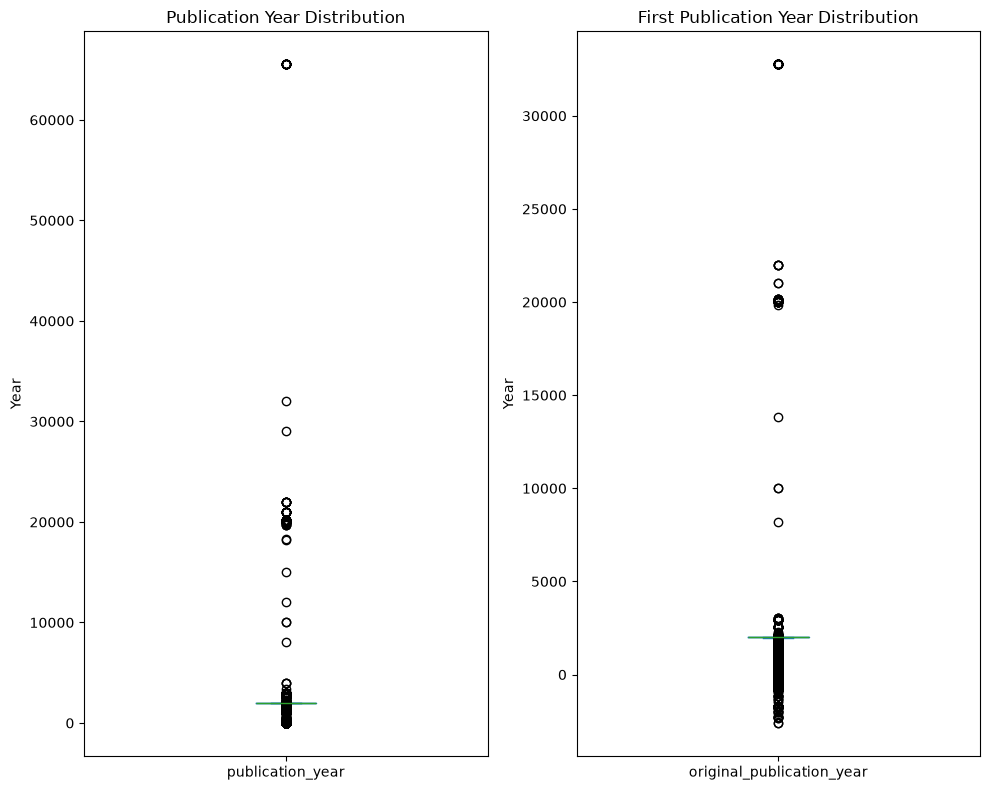

In [8]:
df2 = df.copy()
fig, ax = plt.subplots(1,2, figsize=(10,8))

df2['publication_year'].plot(kind='box', ax=ax[0])
ax[0].set_title('Publication Year Distribution')
ax[0].set_ylabel('Year')

df2['original_publication_year'].plot(kind='box', ax=ax[1])
ax[1].set_title('First Publication Year Distribution')
ax[1].set_ylabel('Year')

fig.tight_layout()
plt.show()

publication year có rất nhiều invalid value, theo tìm hiểu thì có rất nhiều sách điền ttin year trên web sai (vd: https://www.goodreads.com/book/show/16038054) (nhiều sách viết nhầm như 2014 -> 2104)

In [9]:
df2[df2['original_publication_year'] > 2027][['book_id', 'title', 'average_rating', 'publication_year', 'original_publication_year', 'book_url']].sample(5)

,book_id,title,average_rating,publication_year,original_publication_year,book_url
604076,25559488,"The Gift Of Memoir: Show Up, Open Up, Write",5.00,2105.0,2105.0,https://www.goodreads.com/book/show/25559488-t...
1430114,13410137,เงารักเงาเสน่หา,3.00,2552.0,2552.0,https://www.goodreads.com/book/show/13410137
1706198,33838566,Dylan Thomas and the Writing Shed,5.00,2017.0,2107.0,https://www.goodreads.com/book/show/33838566-d...
2056467,28178837,Coles to Jerusalem: A Pilgrimage to the Holy L...,3.87,NaN,2106.0,https://www.goodreads.com/book/show/28178837-c...
1822477,13597896,أرى المعنى,3.56,2102.0,2102.0,https://www.goodreads.com/book/show/13597896


In [4]:
df.loc[df["publication_year"] > 2026, "publication_year"] = np.nan
df.loc[df["original_publication_year"] > 2026, "original_publication_year"] = np.nan
for col in ["country_code", "language_code", "publisher"]:
    df[col] = (df[col].astype("string").str.strip().replace("", np.nan))

In [5]:
df[['num_pages', 'ratings_count']] = df[['num_pages', 'ratings_count']].astype('Int32')
df['average_rating'] = df['average_rating'].astype('float64')
df[['publication_year', 'original_publication_year']] = df[['publication_year', 'original_publication_year']].astype('Int16')

In [6]:
df = df.drop(columns=['title_without_series', 'country_code'])

# EDA

### Data Quality

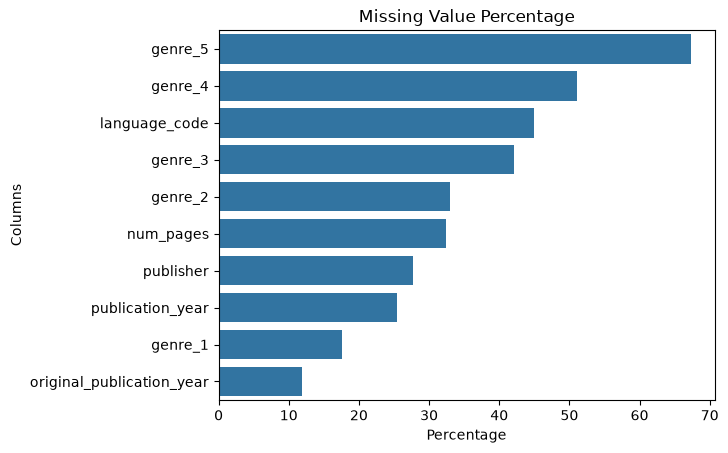

In [13]:
df2 = df.copy()

plot1 = ((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False).head(10)

sns.barplot(x=plot1.values, y=plot1.index)
plt.xlabel('Percentage')
plt.ylabel('Columns')
plt.title('Missing Value Percentage')

plt.tight_layout
plt.show()

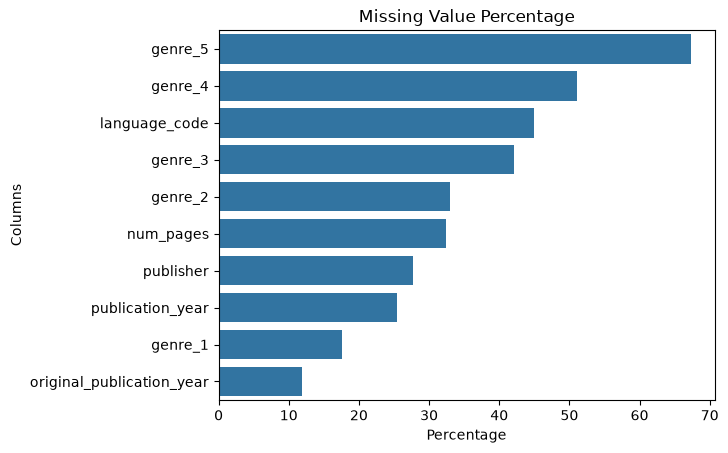

In [14]:
df2 = df.copy()

plot1 = ((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False).head(10)

sns.barplot(x=plot1.values, y=plot1.index)
plt.xlabel('Percentage')
plt.ylabel('Columns')
plt.title('Missing Value Percentage')

plt.tight_layout
plt.show()

### Ratings & Popularity

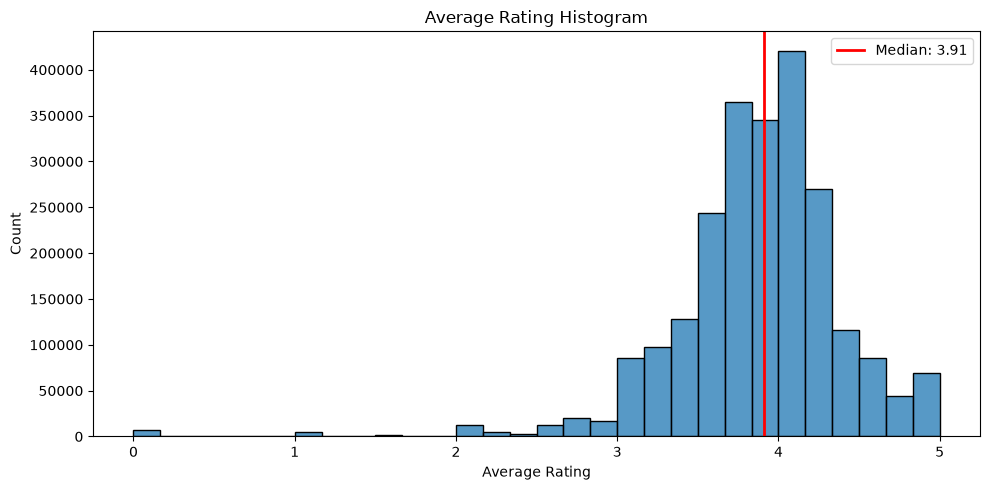

In [15]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(df2['average_rating'], bins=30)
ax.axvline(df2['average_rating'].median(), color='red', linestyle='-', linewidth=2, label=f'Median: {df2['average_rating'].median():.2f}')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Count')
ax.set_title('Average Rating Histogram')
ax.legend()

plt.tight_layout()
plt.show()

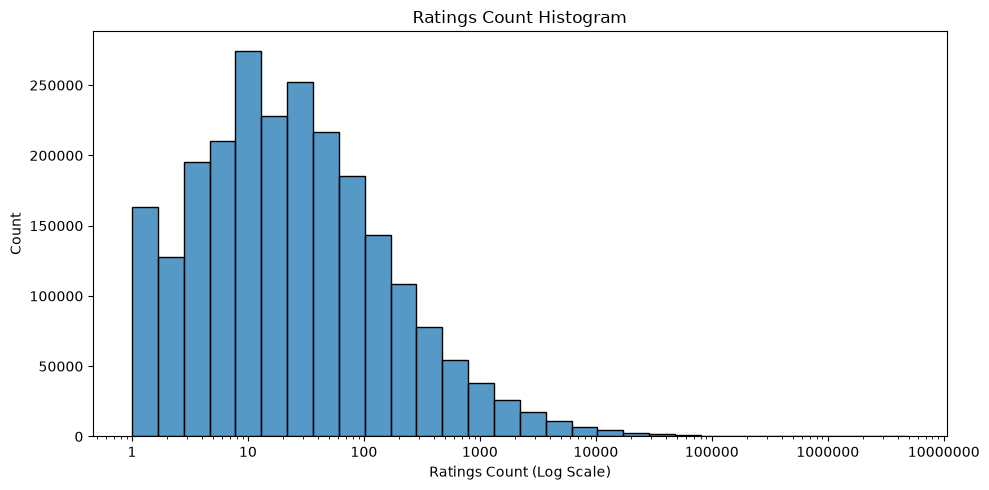

In [16]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df2[df2['ratings_count'] > 0]['ratings_count'], bins=30, log_scale=True, ax=ax)
ax.set_xlabel('Ratings Count (Log Scale)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}'))
ax.set_title('Ratings Count Histogram')

plt.tight_layout()
plt.show()

In [17]:
df2[['original_title', 'ratings_count', 'average_rating']].sort_values(by='ratings_count', ascending=False).head(10)

,original_title,ratings_count,average_rating
1397889,The Hunger Games,4899965,4.34
863121,Harry Potter and the Philosopher's Stone,4765497,4.45
110764,Twilight,3941381,3.57
2303171,To Kill a Mockingbird,3255518,4.26
341747,The Great Gatsby,2758812,3.89
1874695,The Fault in Our Stars,2429317,4.26
1673677,The Hobbit : or There and Back Again,2099680,4.25
396654,The Catcher in the Rye,2086945,3.79
924305,Pride and Prejudice,2078406,4.25
185627,Angels & Demons,2046499,3.86


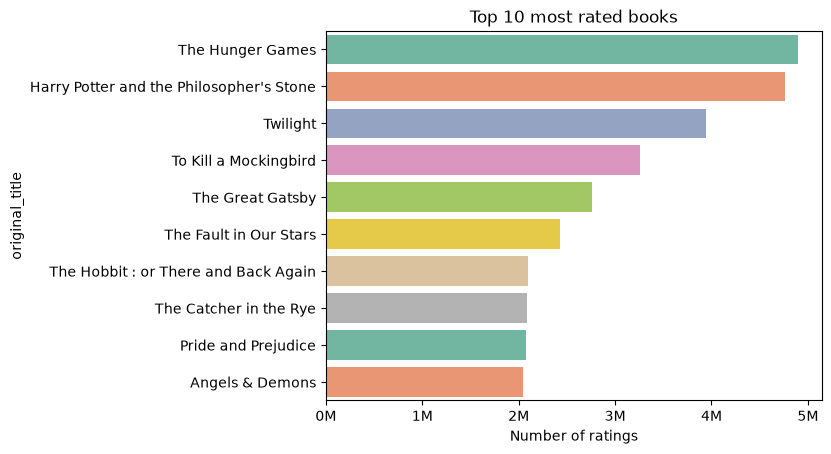

In [15]:
df2 = df.copy()

plot1 = df2[['original_title', 'ratings_count', 'average_rating']].sort_values(by='ratings_count', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='ratings_count', y='original_title', hue='original_title', palette="Set2")
ax.set_xlabel("Number of ratings")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_title("Top 10 most rated books")

plt.show()

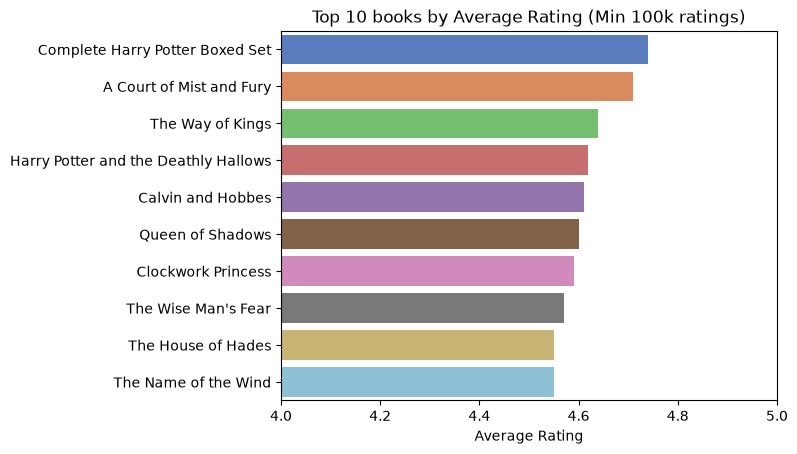

In [14]:
df2 = df.copy()

plot1 = df2[df2['ratings_count'] > 100000][['original_title', 'average_rating']].sort_values(by='average_rating', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='average_rating', y='original_title', hue='original_title', palette='muted')
ax.set_xlim(4, 5)
ax.set_xlabel("Average Rating")
ax.set_ylabel("")
ax.set_title("Top 10 books by Average Rating (Min 100k ratings)")

plt.show()

### Book Characteristics

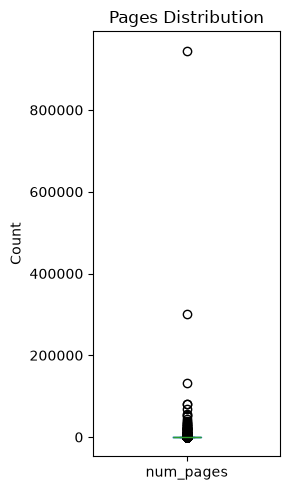

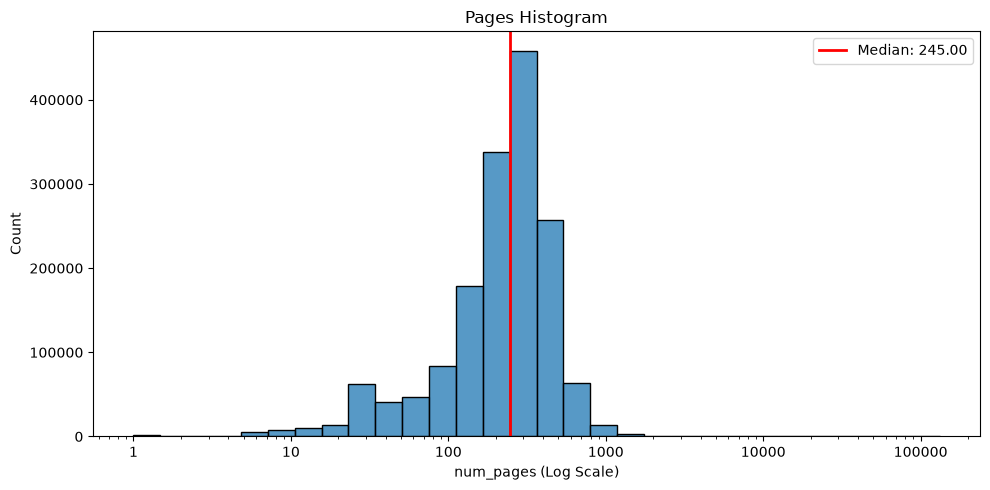

In [20]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(3,5))

df2['num_pages'].plot(kind='box')
ax.set_title('Pages Distribution')
ax.set_ylabel('Count')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df2[(df2['num_pages'] > 0) & (df2['num_pages'] < 200_000)]['num_pages'], bins=30, log_scale=True, ax=ax)
ax.set_xlabel('num_pages (Log Scale)')
ax.axvline(df2['num_pages'].median(), color='red', linestyle='-', linewidth=2, label=f'Median: {df2['num_pages'].median():.2f}')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0f}'))
ax.set_title('Pages Histogram')
ax.legend()
plt.tight_layout()
plt.show()

### Genre Analysis

Top 20 genres

Genre vs average_rating

Genre vs ratings_count

Rating distribution by genre

Genre combinations

### Temporal Analysis

Number of books by publication year

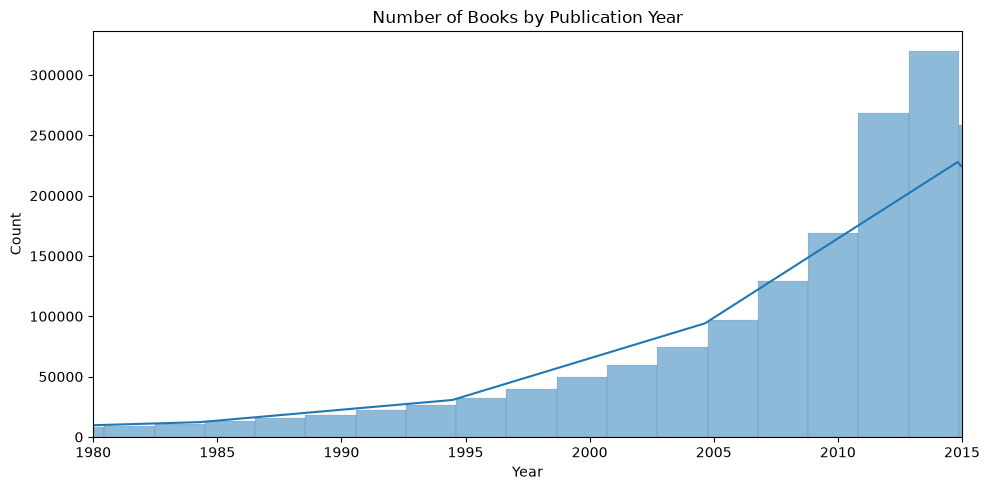

In [28]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(df2['publication_year'], bins=1000, kde=True)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_xlim(1980, 2015)
ax.set_title('Number of Books by Publication Year')

plt.tight_layout()
plt.show()

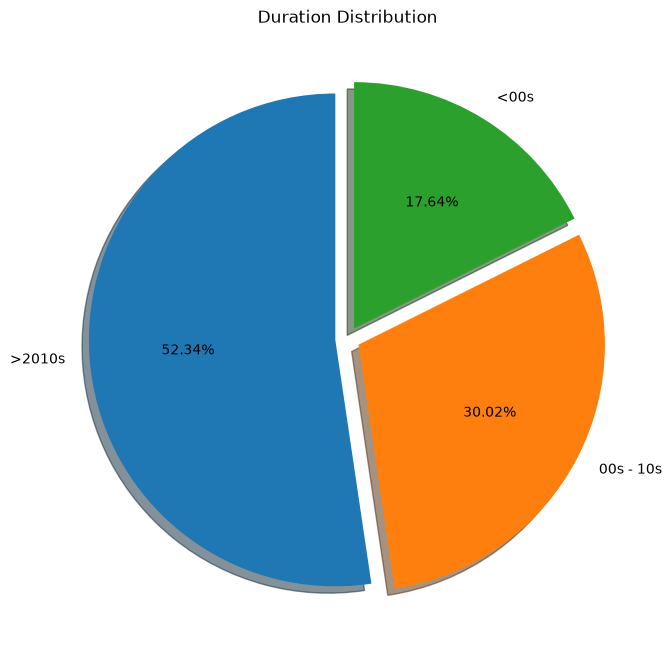

In [27]:
df2 = df.copy()
df2 = df2[df2['publication_year'].notna()]
df2['publication_year_category'] = np.where(df2['publication_year'] > 2010, '>2010s', np.where(df2['publication_year'] > 2000, '00s - 10s', '<00s'))

fig, ax = plt.subplots(figsize=(8,8))
explode_values = (0.05, 0.05, 0.05)
df2['publication_year_category'].value_counts().plot(kind='pie', startangle=90, autopct='%1.2f%%', shadow=True, explode=explode_values)
ax.set_ylabel('')
ax.set_title('Duration Distribution')
plt.show()

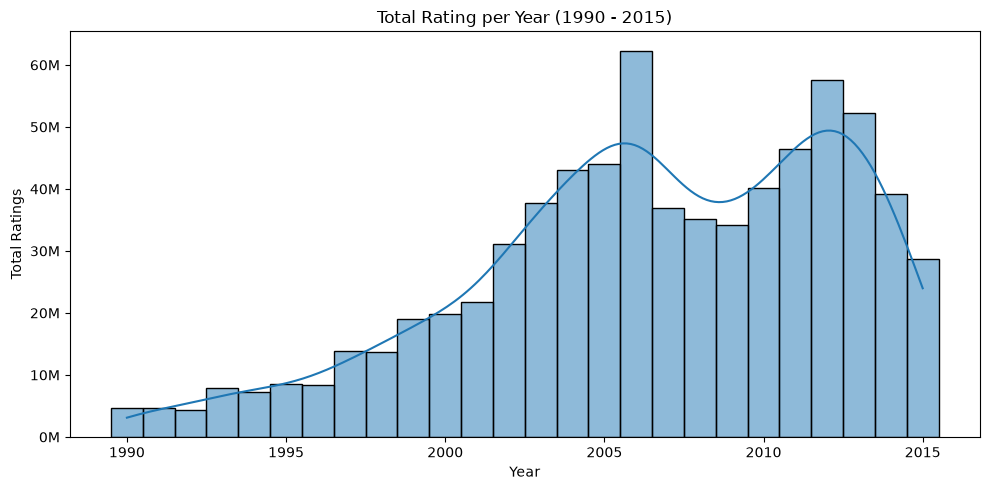

In [10]:
df2 = df.copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(data=df2[(df2['publication_year'] >= 1990) & (df2['publication_year'] <= 2015)], x='publication_year', weights='ratings_count', discrete=True, kde=True, ax=ax)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_xlabel('Year')
ax.set_ylabel('Total Ratings')
ax.set_title('Total Rating per Year (1990 - 2015)')

plt.tight_layout()
plt.show()

### Author / Series

24. Top authors by average rating

In [ ]:
df['author_names'].value_counts(ascending=False).head(10)

In [9]:
df['author_names']

0                                       [Jiddu Krishnamurti]
1          [John Llewellyn Probert, Johnny Mains, Mark We...
2                                          [Garth Callaghan]
3                                     [Thomas J. Craughwell]
4                                        [Nancy Bartholomew]
                                 ...                        
2360650                                    [Scarlett Loxley]
2360651                                     [H.P. Lovecraft]
2360652                                 [Francisco Melendez]
2360653                                       [Cynthia Hand]
2360654                                     [Jesse Richards]
Name: author_names, Length: 2360655, dtype: object

Series vs Standalone

### Metadata

In [9]:
df.columns

Index(['book_id', 'title', 'author_names', 'num_pages', 'average_rating',
       'ratings_count', 'language_code', 'publisher', 'publication_year',
       'book_url', 'image_url', 'genre_1', 'genre_2', 'genre_3', 'genre_4',
       'genre_5', 'series_names', 'original_title',
       'original_publication_year'],
      dtype='str')

Top 20 languages

In [11]:
df['language_code'].value_counts(ascending=False).head(20)

language_code
eng      708457
en-US     91452
en-GB     58358
spa       54524
ita       50902
ara       42978
fre       32046
ger       30941
ind       27291
por       23452
nl        17497
tur       14238
per       11821
fin       11611
gre       10024
swe        9914
cze        8564
en-CA      7652
jpn        7209
bul        7105
Name: count, dtype: int64[pyarrow]

Top 20 publishers

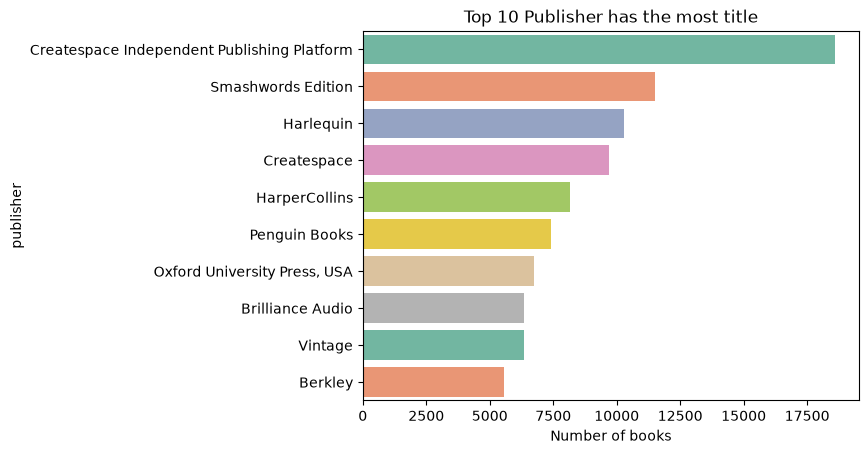

In [ ]:
plot1 = df2['publisher'].value_counts(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set2")
ax.set_xlabel("Number of books")
ax.set_title("Publisher has the most title")

plt.show()

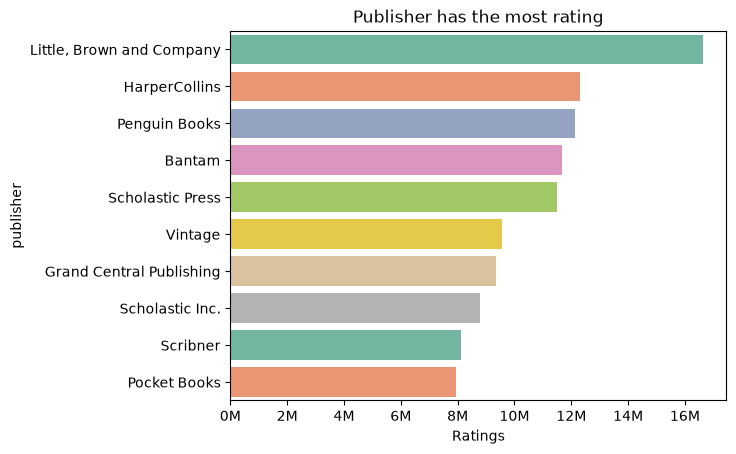

In [28]:
plot1 = df2.groupby('publisher')['ratings_count'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(x=plot1.values, y=plot1.index, hue=plot1.index, palette="Set2")
ax.set_xlabel("Ratings")
ax.set_title("Publisher has the most rating")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))

plt.show()

In [ ]:
df2 = df.copy()

plot1 = df2[['original_title', 'ratings_count', 'average_rating']].sort_values(by='ratings_count', ascending=False).head(10)
fig, ax = plt.subplots()
sns.barplot(data=plot1, x='ratings_count', y='original_title', hue='original_title', palette="Set2")
ax.set_xlabel("Number of ratings")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M'))
ax.set_title("Top 10 most rated books")

plt.show()

Publisher vs popularity